<a href="https://colab.research.google.com/github/boba-frog/Fraud-Detection/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file on Google Drive
file_path = '/content/drive/MyDrive/DATASET/financial_fraud_detection_dataset.csv' # Replace with the actual path

# Load the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Mounted at /content/drive
DataFrame loaded successfully!
  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            online   Sydney         pos     False   
4    24.43         transfer         utilities  Toronto      mo

In [ ]:
#ENCODING PT1
#Configuring the variables for Machine Learning.
# Categorical columns identified from the previous step:
# ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']

# Plan for encoding categorical columns:
# transaction_id: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering if needed. For this task, we'll plan to drop it.
# timestamp: Time-series data. Requires specific handling (e.g., extracting features like hour, day of week). For this task, we'll plan to drop it for simplicity in this subtask.
# sender_account, receiver_account: High cardinality, likely not useful as direct features. Consider dropping or using feature engineering (e.g., aggregation). For this task, we'll plan to drop them.
# transaction_type: Low cardinality, nominal. Use one-hot encoding.
# merchant_category: Moderate cardinality, nominal. Use one-hot encoding.
# location: High cardinality. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_used: Moderate cardinality, nominal. Use one-hot encoding.
# is_fraud: Target variable (boolean). Can be treated as 0/1 for classification. No encoding needed for the target variable itself, but it's important to identify it.
# fraud_type: Moderate cardinality, nominal. Use one-hot encoding.
# payment_channel: Low cardinality, nominal. Use one-hot encoding.
# ip_address: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.
# device_hash: High cardinality, likely not useful as a direct feature. Consider dropping or using feature engineering. For this task, we'll plan to drop it.

# Columns to drop due to high cardinality or irrelevance for direct encoding:
cols_to_drop = ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']

# Columns for one-hot encoding:
cols_for_onehot = ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']

# Target variable (no encoding needed for the variable itself):
target_col = 'is_fraud'

print("Plan for encoding categorical variables:")
print(f"Columns to be dropped: {cols_to_drop}")
print(f"Columns for one-hot encoding: {cols_for_onehot}")
print(f"Target variable: {target_col}")

Plan for encoding categorical variables:
Columns to be dropped: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'location', 'ip_address', 'device_hash']
Columns for one-hot encoding: ['transaction_type', 'merchant_category', 'device_used', 'fraud_type', 'payment_channel']
Target variable: is_fraud


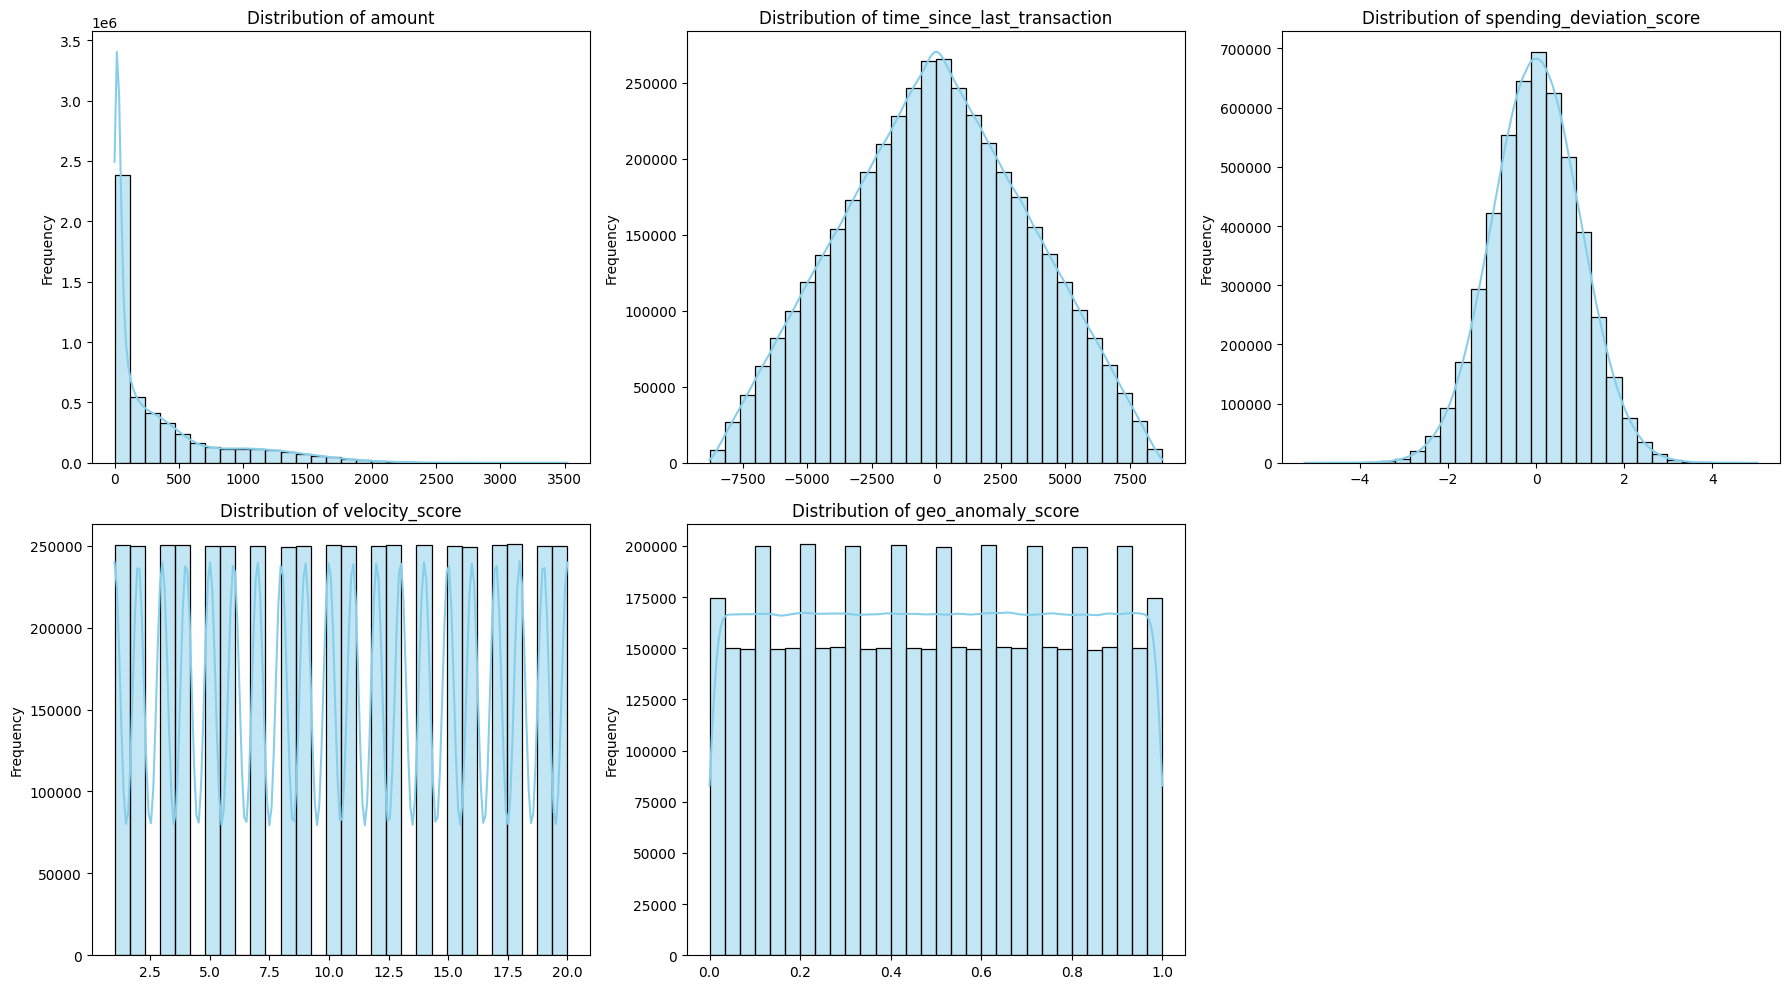

In [ ]:
#DO NOT RUN IN NORMAL CODE
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns to visualize
num_cols = ['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score']

# Set up the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_encoded[col], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Remove the last empty subplot if num_cols is less than grid size
if len(num_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

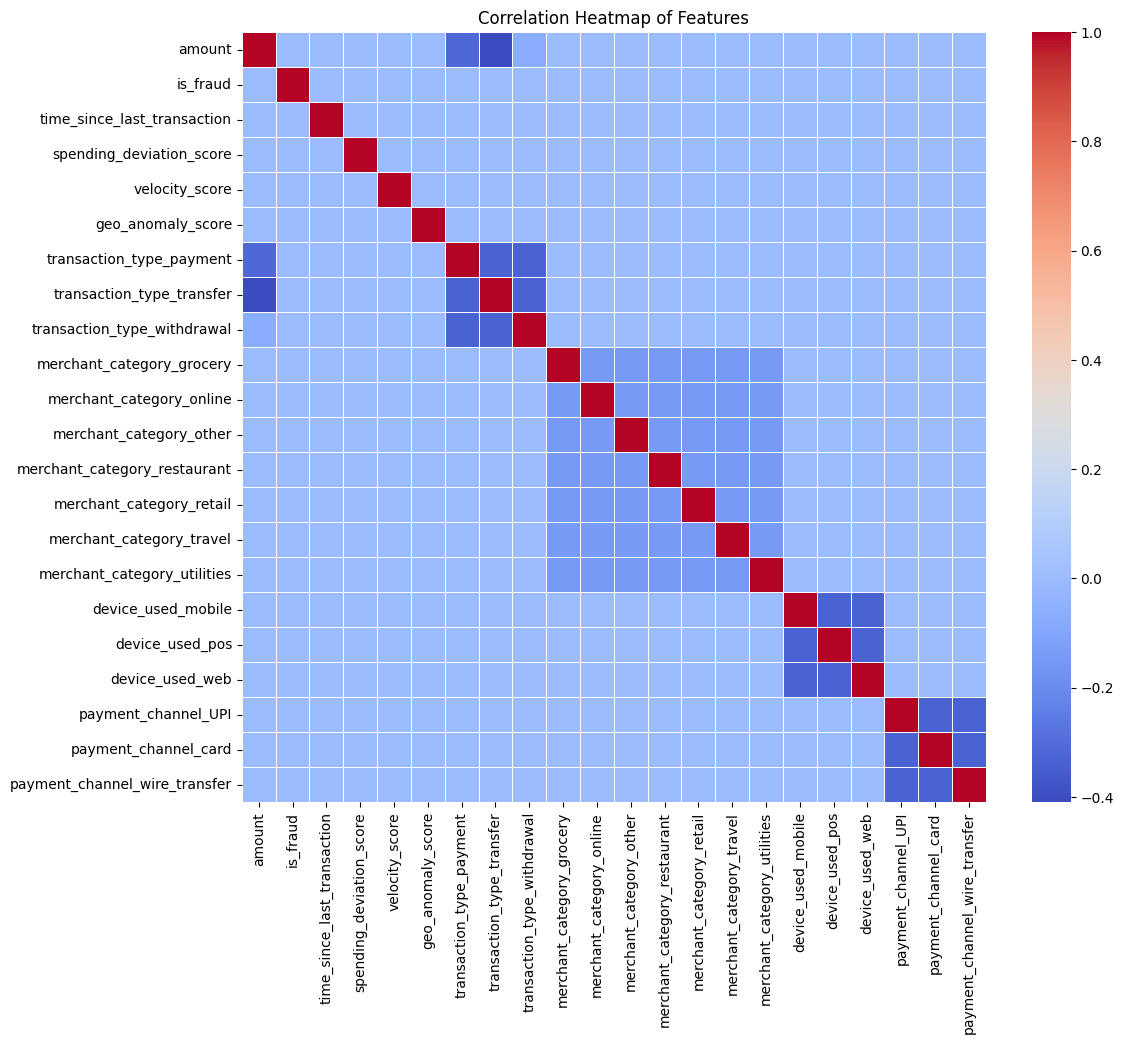

In [ ]:
#DO NOT RUN IN NORMAL CODE
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
#ENCODING PT2
# Converting USEFUL columns into usable data.
# Drop the columns identified for dropping
df_encoded = df.drop(columns=cols_to_drop)

# Apply one-hot encoding to the columns identified for one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=cols_for_onehot, drop_first=True)

# Display the first few rows of the encoded DataFrame to verify
print("DataFrame after dropping and one-hot encoding:")
display(df_encoded.head())

# Display the data types of the encoded DataFrame to verify
print("\nData types of the encoded DataFrame:")
print(df_encoded.dtypes)

DataFrame after dropping and one-hot encoding:


,amount,is_fraud,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,transaction_type_payment,transaction_type_transfer,transaction_type_withdrawal,merchant_category_grocery,...,merchant_category_restaurant,merchant_category_retail,merchant_category_travel,merchant_category_utilities,device_used_mobile,device_used_pos,device_used_web,payment_channel_UPI,payment_channel_card,payment_channel_wire_transfer
0,343.78,False,NaN,-0.21,3,0.22,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False
1,419.65,False,NaN,-0.14,7,0.96,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,2773.86,False,NaN,-1.78,20,0.89,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,1666.22,False,NaN,-0.60,6,0.37,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,24.43,False,NaN,0.79,13,0.27,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False



Data types of the encoded DataFrame:
amount                           float64
is_fraud                            bool
time_since_last_transaction      float64
spending_deviation_score         float64
velocity_score                     int64
geo_anomaly_score                float64
transaction_type_payment            bool
transaction_type_transfer           bool
transaction_type_withdrawal         bool
merchant_category_grocery           bool
merchant_category_online            bool
merchant_category_other             bool
merchant_category_restaurant        bool
merchant_category_retail            bool
merchant_category_travel            bool
merchant_category_utilities         bool
device_used_mobile                  bool
device_used_pos                     bool
device_used_web                     bool
payment_channel_UPI                 bool
payment_channel_card                bool
payment_channel_wire_transfer       bool
dtype: object


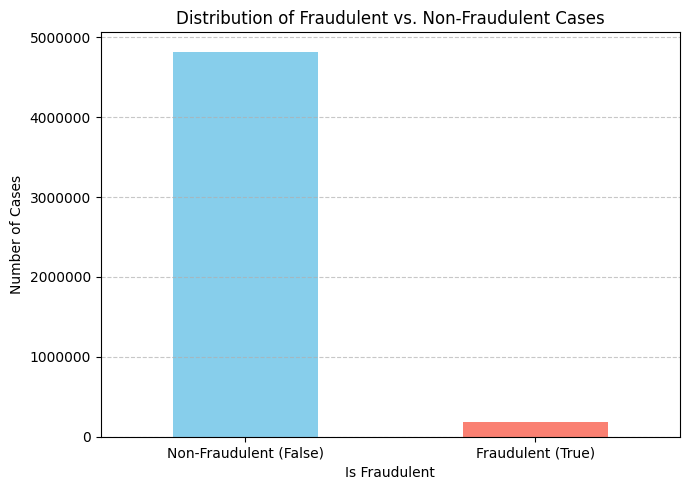

In [ ]:
#DO NOT RUN IN NORMAL CODE
import matplotlib.pyplot as plt

# Get the counts of fraudulent and non-fraudulent cases
fraud_counts = df_encoded['is_fraud'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(7, 5))
fraud_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Cases')
plt.xlabel('Is Fraudulent')
plt.ylabel('Number of Cases')
plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent (False)', 'Fraudulent (True)'], rotation=0)

# Fix y-axis to show real numbers instead of scientific notation
plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!pip install imbalanced-learn

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, f1_score, auc, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Data preparation
# -----------------------
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# Impute missing values
X['time_since_last_transaction'] = X['time_since_last_transaction'].fillna(
    X['time_since_last_transaction'].mean()
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------
# Sampling & SMOTE
# -----------------------
# Take a 5% sample of training set for faster SMOTE/NN training
X_train_samp, _, y_train_samp, _ = train_test_split(
    X_train, y_train, train_size=0.05, random_state=42, stratify=y_train
)

# Apply SMOTE to the sampled data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_samp, y_train_samp)

# Scale features (critical for NN)
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"Original training sample shape: {Counter(y_train_samp)}")
print(f"Resampled training shape after SMOTE: {Counter(y_train_res)}")

# -----------------------
# Neural Network Training
# -----------------------
# Base MLPClassifier with reasonable settings
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=200,
    activation='relu',
    solver='adam',
    alpha=0.0001,
    random_state=42
)

# Optional: Hyperparameter tuning via GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(100,), (100,50), (150,75)],
    'alpha': [0.0001, 0.001, 0.01],
    'activation': ['relu', 'tanh']
}

grid_search = GridSearchCV(
    mlp,
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit the GridSearch on resampled, scaled data
grid_search.fit(X_train_res_scaled, y_train_res)
best_model = grid_search.best_estimator_

print(f"\nBest hyperparameters found: {grid_search.best_params_}")

# -----------------------
# Threshold tuning for F1-score
# -----------------------
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

best_thresh = 0.5
best_f1 = 0
thresholds = np.linspace(0.01, 0.99, 99)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nOptimal threshold = {best_thresh:.2f} with F1 = {best_f1:.4f}")

y_pred_best = (y_proba >= best_thresh).astype(int)

# -----------------------
# Evaluation
# -----------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Precision-Recall curve & PR-AUC
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision_vals)
print(f"\nPrecision-Recall AUC: {pr_auc:.4f}")

# -----------------------
# Plot Precision-Recall vs Threshold
# -----------------------
plt.figure(figsize=(8,6))
plt.plot(pr_thresholds, precision_vals[:-1], label="Precision")
plt.plot(pr_thresholds, recall_vals[:-1], label="Recall")
plt.axvline(best_thresh, color='red', linestyle='--', label=f"Best Thresh = {best_thresh:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimized Neural Network: Precision & Recall vs Threshold")
plt.legend()
plt.show()

# -----------------------
# Plot ROC Curve
# -----------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

KeyboardInterrupt: 

Original training sample shape: Counter({False: 38564, True: 1436})
Resampled training shape after SMOTE: Counter({False: 38564, True: 38564})
Training MLP model...

Optimal threshold = 0.01 with F1 = 0.0677

Confusion Matrix:
[[424676 539413]
 [ 15759  20152]]

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.44      0.60    964089
        True       0.04      0.56      0.07     35911

    accuracy                           0.44   1000000
   macro avg       0.50      0.50      0.34   1000000
weighted avg       0.93      0.44      0.59   1000000



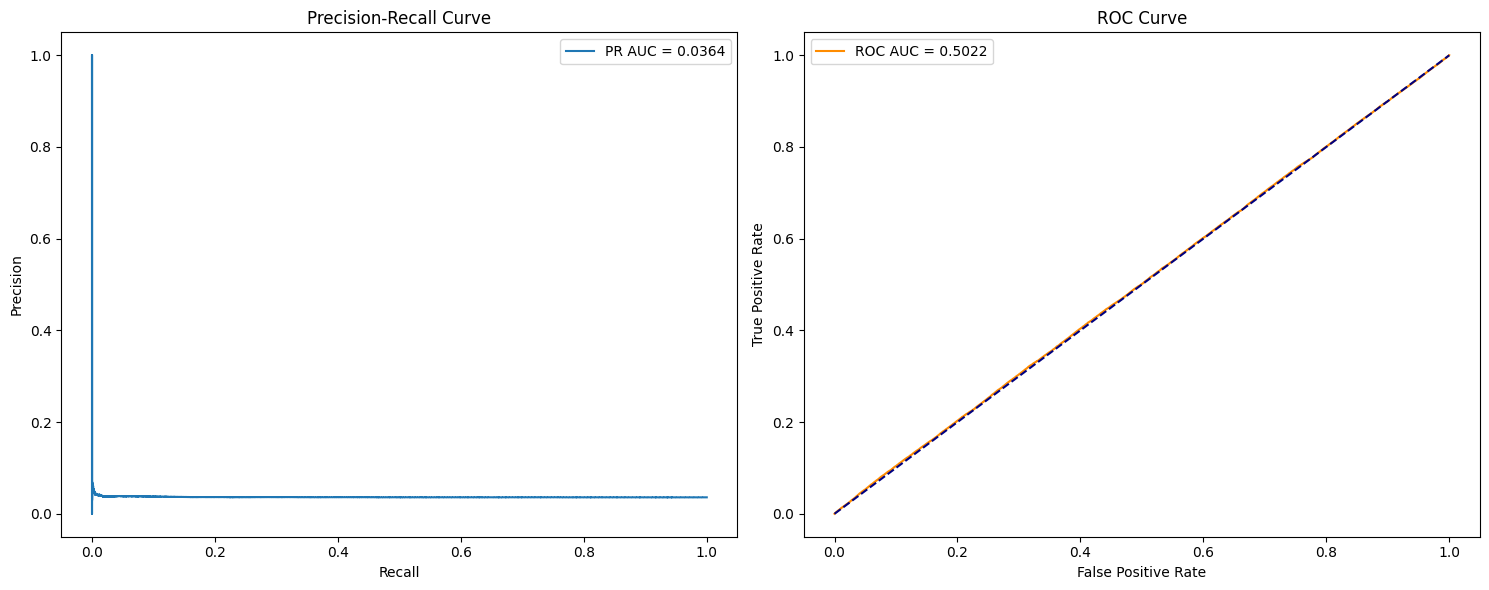

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, f1_score, auc, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Data preparation
# -----------------------
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# Impute missing values
X['time_since_last_transaction'] = X['time_since_last_transaction'].fillna(
    X['time_since_last_transaction'].mean()
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------
# Sampling & SMOTE (Optimized for speed)
# -----------------------
# Reduced to 1% sample for significantly faster prototyping
X_train_samp, _, y_train_samp, _ = train_test_split(
    X_train, y_train, train_size=0.01, random_state=42, stratify=y_train
)

# Apply SMOTE to the sampled data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_samp, y_train_samp)

# Scale features (critical for NN)
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"Original training sample shape: {Counter(y_train_samp)}")
print(f"Resampled training shape after SMOTE: {Counter(y_train_res)}")

# -----------------------
# Neural Network Training (Direct with Optimized Parameters)
# -----------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=200,
    activation='relu',
    solver='adam',
    alpha=0.001,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

print("Training MLP model...")
mlp.fit(X_train_res_scaled, y_train_res)
best_model = mlp

# -----------------------
# Threshold tuning for F1-score
# -----------------------
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

best_thresh = 0.5
best_f1 = 0
thresholds = np.linspace(0.01, 0.99, 99)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\nOptimal threshold = {best_thresh:.2f} with F1 = {best_f1:.4f}")

y_pred_best = (y_proba >= best_thresh).astype(int)

# -----------------------
# Evaluation & Visualizations
# -----------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Precision-Recall & ROC plots
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot PR Curve
ax1.plot(recall, precision, label=f'PR AUC = {auc(recall, precision):.4f}')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve')
ax1.legend()

# Plot ROC Curve
ax2.plot(fpr, tpr, color='darkorange', label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.4f}')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.show()